In [1]:
#This notebook uses clustering to segment FinMark customers based on transaction behavior and satisfaction, 
#aiming to identify groups like high-value, frequent, and low-activity customers.

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

#clustering
from sklearn.cluster import KMeans
from scipy.stats import f_oneway
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score

In [28]:
df = pd.read_csv("FinMark_WEEK3_Final.csv")

df.head()

,Customer_ID,Satisfaction_Score,Feedback_Comments,Likelihood_to_Recommend,Transaction_ID,Transaction_Date,Transaction_Amount,Transaction_Type,FirstTransactionDate,AccountAgeDays,TotalTransactionAmount,TransactionCount
0,1,10.0,Very satisfied,9,29.0,2023-01-02 04:00:00,156.0,Loan Payment,2023-01-02 04:00:00,1120,33672.0,12
1,1,10.0,Very satisfied,9,282.0,2023-01-12 17:00:00,1572.0,Bill Payment,2023-01-02 04:00:00,1120,33672.0,12
2,1,10.0,Very satisfied,9,2883.0,2023-05-01 02:00:00,4867.0,Bill Payment,2023-01-02 04:00:00,1120,33672.0,12
3,1,10.0,Very satisfied,9,3135.0,2023-05-11 14:00:00,1278.0,Investment,2023-01-02 04:00:00,1120,33672.0,12
4,1,10.0,Very satisfied,9,3626.0,2023-06-01 01:00:00,3970.0,Purchase,2023-01-02 04:00:00,1120,33672.0,12


In [56]:
# Feature Engineering: Median Transaction Amount per Customer

median_transaction = df.groupby('Customer_ID')['Transaction_Amount'].median().reset_index()
median_transaction.rename(columns={'Transaction_Amount': 'MedianTransactionAmount'}, inplace=True)

# Merge back to main dataframe
df = df.merge(median_transaction, on='Customer_ID', how='left')

df[['Customer_ID','MedianTransactionAmount']].head()

,Customer_ID,MedianTransactionAmount
0,1,2771.0
1,1,2771.0
2,1,2771.0
3,1,2771.0
4,1,2771.0


In [57]:
features = [
    'TotalTransactionAmount',
    'TransactionCount',
    'MedianTransactionAmount',
    'Satisfaction_Score'
]

X = df[features]

In [58]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[0.01146439, 0.08396947, 0.55497697, 0.15254237],
       [0.01146439, 0.08396947, 0.55497697, 0.15254237],
       [0.01146439, 0.08396947, 0.55497697, 0.15254237],
       [0.01146439, 0.08396947, 0.55497697, 0.15254237],
       [0.01146439, 0.08396947, 0.55497697, 0.15254237]])

In [62]:
# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    pca.components_,
    columns=features,
    index=['PC1','PC2']
)

print("PCA Feature Contributions:")
print(pca_df)


PCA Feature Contributions:
     TotalTransactionAmount  TransactionCount  MedianTransactionAmount  \
PC1                0.100443          0.196187                 0.975400   
PC2                0.212695          0.953450                -0.213645   

     Satisfaction_Score  
PC1            0.004096  
PC2           -0.007063  


In [68]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

sil_score = silhouette_score(X_scaled, df['Cluster'])
ch_score = calinski_harabasz_score(X_scaled, df['Cluster'])

print("Silhouette Score:", round(sil_score, 3))
print("Calinski-Harabasz Score:", round(ch_score, 3))

Silhouette Score: 0.207
Calinski-Harabasz Score: 4973.158


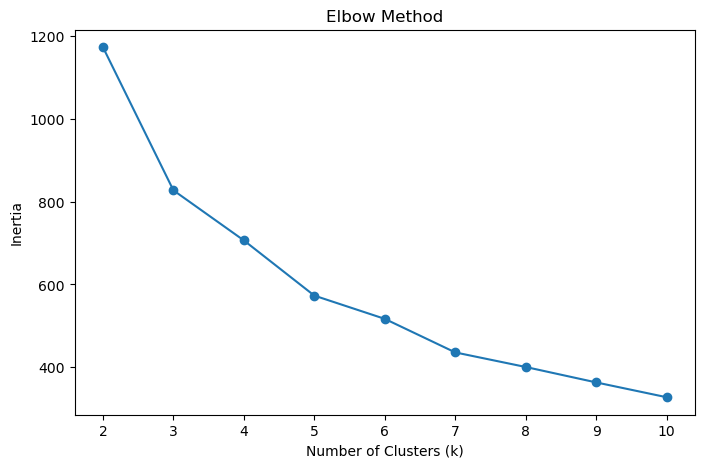

In [69]:
#Elbow Method
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [54]:
#Apply K Means Clustering

k = 4  # change if elbow suggests a different number
kmeans = KMeans(n_clusters=k, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)
df.head()

,Customer_ID,Satisfaction_Score,Feedback_Comments,Likelihood_to_Recommend,Transaction_ID,Transaction_Date,Transaction_Amount,Transaction_Type,FirstTransactionDate,AccountAgeDays,TotalTransactionAmount,TransactionCount,Cluster
0,1,10.0,Very satisfied,9,29.0,2023-01-02 04:00:00,156.0,Loan Payment,2023-01-02 04:00:00,1120,33672.0,12,0
1,1,10.0,Very satisfied,9,282.0,2023-01-12 17:00:00,1572.0,Bill Payment,2023-01-02 04:00:00,1120,33672.0,12,0
2,1,10.0,Very satisfied,9,2883.0,2023-05-01 02:00:00,4867.0,Bill Payment,2023-01-02 04:00:00,1120,33672.0,12,0
3,1,10.0,Very satisfied,9,3135.0,2023-05-11 14:00:00,1278.0,Investment,2023-01-02 04:00:00,1120,33672.0,12,0
4,1,10.0,Very satisfied,9,3626.0,2023-06-01 01:00:00,3970.0,Purchase,2023-01-02 04:00:00,1120,33672.0,12,0


In [55]:

# Split data by cluster
cluster0 = df[df['Cluster'] == 0]
cluster1 = df[df['Cluster'] == 1]
cluster2 = df[df['Cluster'] == 2]
cluster3 = df[df['Cluster'] == 3]

# Function to compute ANOVA and return results
def run_anova(variable):
    F_stat, p_value = f_oneway(
        cluster0[variable],
        cluster1[variable],
        cluster2[variable],
        cluster3[variable]
    )
    conclusion = "Significant differences exist between clusters" if p_value < 0.05 else "No significant differences"
    return F_stat, p_value, conclusion

# Variables to test
variables = ['TransactionCount', 'TotalTransactionAmount', 'Satisfaction_Score']

# Create results table
anova_results = []
for var in variables:
    F_stat, p_value, conclusion = run_anova(var)
    anova_results.append([var, round(F_stat, 2), round(p_value, 4), conclusion])

# Convert to dataframe for easy display
anova_df = pd.DataFrame(anova_results, columns=['Variable', 'F-Statistic', 'P-Value', 'Conclusion'])
print(anova_df)

                 Variable  F-Statistic  P-Value  \
0        TransactionCount     24300.99   0.0000   
1  TotalTransactionAmount     67267.43   0.0000   
2      Satisfaction_Score         6.58   0.0002   

                                       Conclusion  
0  Significant differences exist between clusters  
1  Significant differences exist between clusters  
2  Significant differences exist between clusters  


In [39]:
#Check Cluster Sizes
df['Cluster'].value_counts()

Cluster
0    12924
2    10293
3     1524
1      259
Name: count, dtype: int64

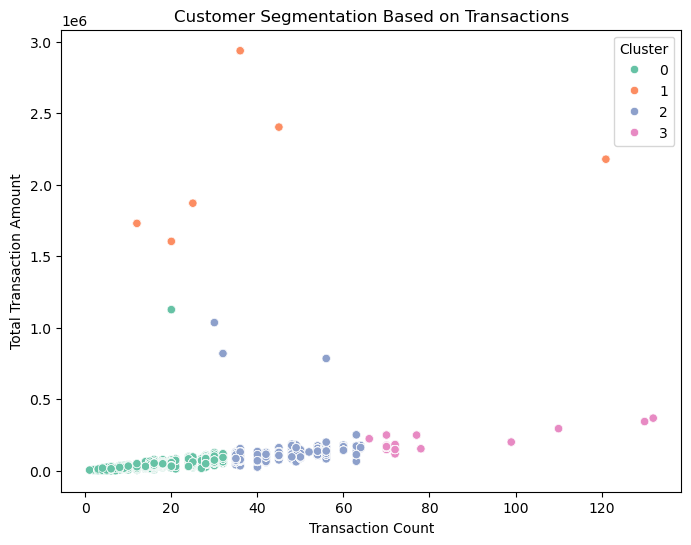

In [43]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='TransactionCount',
    y='TotalTransactionAmount',
    hue='Cluster',
    palette='Set2'
)

plt.title("Customer Segmentation Based on Transactions")
plt.xlabel("Transaction Count")
plt.ylabel("Total Transaction Amount")
plt.show()

In [48]:
#Analyze Cluster Profiles
cluster_avg = df.groupby('Cluster')[[
    'TransactionCount',
    'TotalTransactionAmount',
    'Satisfaction_Score'
]].mean().round(2)

cluster_avg

,TransactionCount,TotalTransactionAmount,Satisfaction_Score
Cluster,,,
0,20.75,53088.44,5.70
1,73.86,2228127.65,6.07
2,45.62,121029.10,5.62
3,86.57,214913.06,6.02


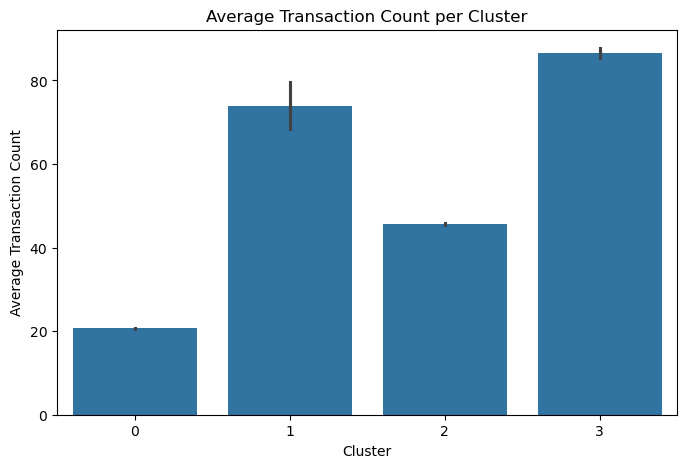

In [49]:
#Transaction Count by Cluster

plt.figure(figsize=(8,5))
sns.barplot(x='Cluster', y='TransactionCount', data=df, estimator='mean')
plt.title("Average Transaction Count per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Transaction Count")
plt.show()

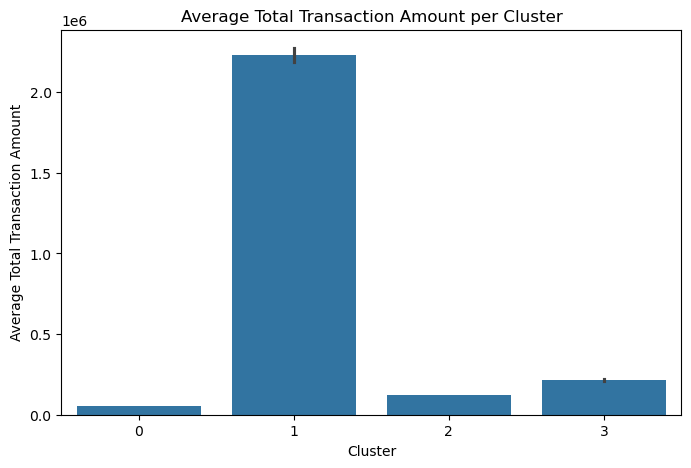

In [50]:
#Total Transaction Amount by Cluster

plt.figure(figsize=(8,5))
sns.barplot(x='Cluster', y='TotalTransactionAmount', data=df, estimator='mean')
plt.title("Average Total Transaction Amount per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Total Transaction Amount")
plt.show()

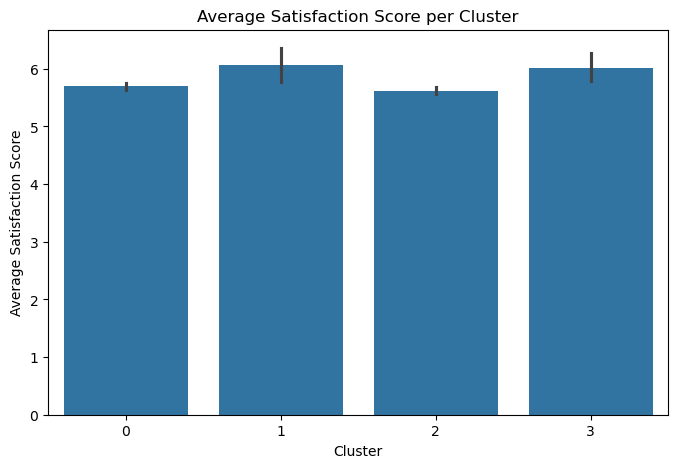

In [51]:
#Satisfaction Score by Cluster

plt.figure(figsize=(8,5))
sns.barplot(x='Cluster', y='Satisfaction_Score', data=df, estimator='mean')
plt.title("Average Satisfaction Score per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Satisfaction Score")
plt.show()